<a href="https://colab.research.google.com/github/evacragnolino/Data-Science-Foundations/blob/main/Unit8_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What predicts the 2016 election?

The 2016 election shocked a lot of people by defying prevous polling and political analysis. The GOP won up and down the ballot winning the presidency, maintaining the senate and the house and won a lot of state elections. In this project I want to see if county wide data can help predict the results of the 2016 election.

In [1]:
!pip install pymc-bart
import pymc_bart as pmb

In [2]:
!pip install bambi

In [3]:
import bambi as bmb

In [4]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv


In [5]:
counties = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')




In [6]:
counties

,name,fips,state,land_area (km^2),area (km^2),longitude (deg),latitude (deg),noaa/prcp,noaa/snow,noaa/temp,...,"industry/Agriculture, forestry, fishing and hunting/payroll","industry/Agriculture, forestry, fishing and hunting/employees",industry/Utilities/payroll,industry/Utilities/employees,industry/Management of companies and enterprises/payroll,industry/Management of companies and enterprises/employees,industry/Industries not classified/payroll,industry/Industries not classified/employees,"industry/Mining, quarrying, and oil and gas extraction/payroll","industry/Mining, quarrying, and oil and gas extraction/employees"
0,cuming county,31039,NE,1477.641638,1488.343176,-96.787366,41.916346,30.5,28.2,48.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lancaster county,31109,NE,2169.252486,2192.120047,-96.688211,40.784132,31.0,25.3,51.0,...,730000.0,111.0,8730000.0,95.0,165117000.0,2024.0,150000.0,3.0,NaN,NaN
2,nuckolls county,31129,NE,1489.645186,1491.363670,-98.047277,40.176383,27.7,22.2,51.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,keith county,31101,NE,2749.531887,2874.204062,-101.657059,41.198294,20.0,25.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,phelps county,31137,NE,1398.048570,1399.695104,-99.414593,40.513105,25.5,26.7,50.3,...,2557000.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3137,washington county,44009,RI,852.825659,1457.597303,-71.627758,41.385053,49.0,30.2,50.2,...,4339000.0,67.0,11574000.0,95.0,60844000.0,953.0,72000.0,3.0,3373000.0,44.0
3138,providence county,44007,RI,1060.791694,1128.431056,-71.569018,41.870350,52.6,46.7,49.2,...,521000.0,22.0,128342000.0,1101.0,975031000.0,11783.0,527000.0,15.0,7485000.0,97.0
3139,bristol county,44001,RI,62.513687,115.859939,-71.288552,41.704331,48.5,36.6,51.9,...,NaN,NaN,NaN,NaN,1919000.0,31.0,283000.0,4.0,NaN,NaN
3140,newport county,44005,RI,265.310311,812.295558,-71.286460,41.506366,47.4,36.6,51.6,...,1583000.0,29.0,5971000.0,75.0,10559000.0,225.0,346000.0,14.0,NaN,NaN


In [7]:
# 1. Remove colons from column names and strip all whitespace (including newlines)
counties.columns = counties.columns.str.replace(':', '', regex=False).str.strip()

# 2. Identify columns with a lot of NaN values (e.g., more than 70% missing)
missing_percentages = counties.isnull().sum() / len(counties)
threshold = 0.70  # Define 'a lot of NaN' as 70% missing values
columns_to_drop = missing_percentages[missing_percentages > threshold].index

# Drop the identified columns to create counties_cleaned
counties_cleaned = counties.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns with more than {threshold*100}% NaN values.\n")

# Combined list of all requested columns
all_requested_columns = [
    'elections/2016/total',
    'elections/2016/gop',
    'avg_income',
    'edu/less-than-high-s',
    'bls/2020/unemployed',
    'life-expectancy',
    'health/ teen birth rate',
    'poverty-rate',
    'cost-of-living/living_wage',
    'health/Violent Crime Rate',
    'edu/bachelors+'
]

# Filter out any columns from the combined list that do not exist in counties_cleaned
existing_columns = [col for col in all_requested_columns if col in counties_cleaned.columns]

# Select only the existing specified columns
counties_final = counties_cleaned[existing_columns]

print("Columns requested but not found in the dataset:")
not_found_columns = [col for col in all_requested_columns if col not in counties_cleaned.columns]
if not_found_columns:
    print(not_found_columns)
else:
    print("None")

print("\nInfo of the final cleaned DataFrame:")
counties_final.info()

Dropped 2 columns with more than 70.0% NaN values.

Columns requested but not found in the dataset:
['edu/less-than-high-s', 'health/ teen birth rate']

Info of the final cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   elections/2016/total        3112 non-null   float64
 1   elections/2016/gop          3112 non-null   float64
 2   avg_income                  3142 non-null   int64  
 3   bls/2020/unemployed         3136 non-null   float64
 4   life-expectancy             3142 non-null   float64
 5   poverty-rate                3141 non-null   float64
 6   cost-of-living/living_wage  3142 non-null   float64
 7   health/Violent Crime Rate   2950 non-null   float64
 8   edu/bachelors+              3142 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 221.1 KB


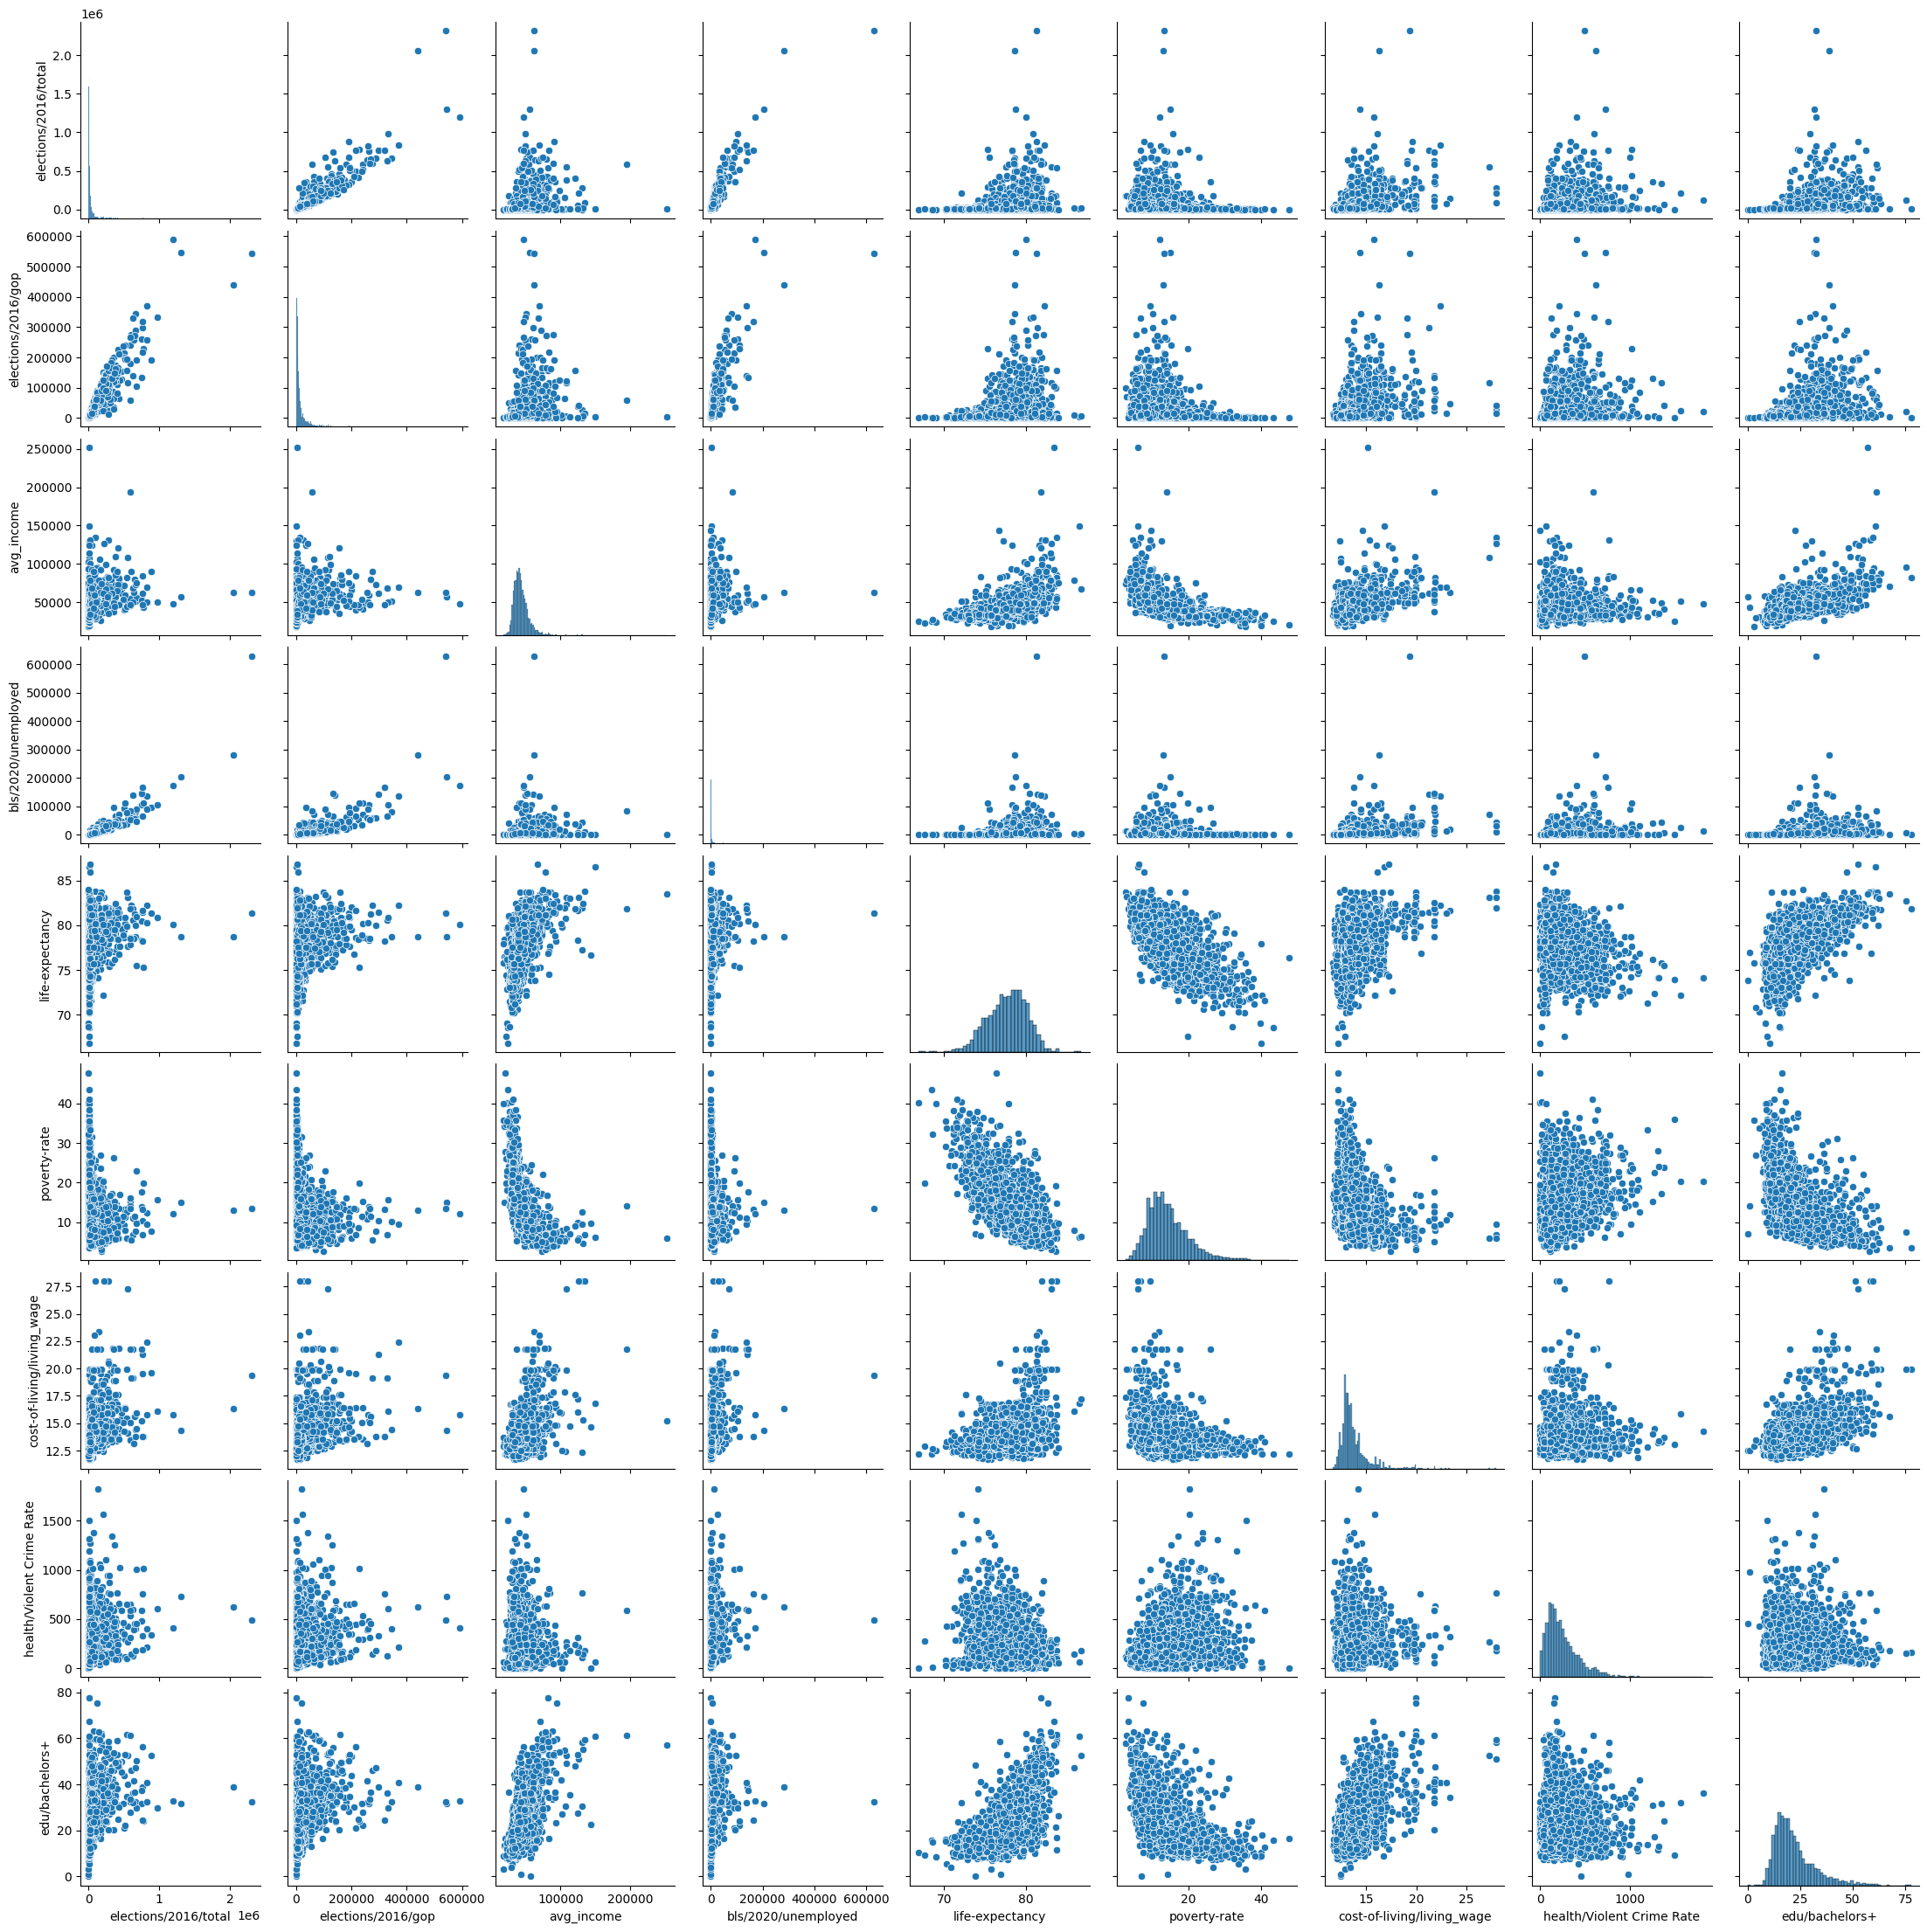

In [8]:
sns.pairplot(counties_final)

In [9]:
counties_final

,elections/2016/total,elections/2016/gop,avg_income,bls/2020/unemployed,life-expectancy,poverty-rate,cost-of-living/living_wage,health/Violent Crime Rate,edu/bachelors+
0,3988.0,3095.0,58610,122.0,81.20,8.9,12.89,22.125118,23.8
1,129803.0,60456.0,49889,7499.0,80.46,10.7,14.72,325.955385,39.5
2,2153.0,1709.0,50836,66.0,80.12,11.2,12.89,NaN,20.9
3,3945.0,3203.0,45896,147.0,79.24,11.1,13.40,105.741121,20.5
4,4609.0,3832.0,52792,148.0,79.86,10.0,12.89,97.097853,23.5
...,...,...,...,...,...,...,...,...,...
3137,64160.0,27074.0,64158,5139.0,81.14,8.0,14.84,75.128806,46.1
3138,241818.0,90321.0,48137,32616.0,79.26,14.0,14.73,312.126481,29.0
3139,24691.0,8910.0,78805,1896.0,81.16,6.8,14.73,70.294831,49.0
3140,39761.0,14975.0,68679,3464.0,81.15,8.5,15.37,163.813083,48.1


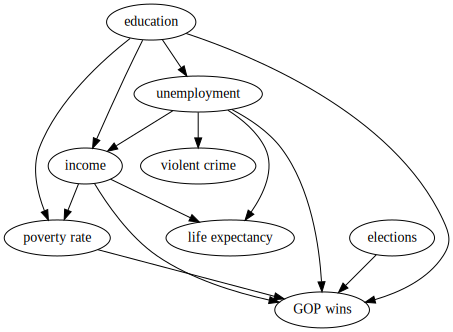

In [10]:
countydag = gv.Digraph(name="CoutyDAG")

countydag.node('I','income')
countydag.node('U','unemployment')
countydag.node('L','life expectancy')
countydag.node('E','education')
countydag.node('P','poverty rate')
countydag.node('V','violent crime')
countydag.node('X','elections')
countydag.node('G','GOP wins')

countydag.edges(['EU', 'UI','EI','UL','UV','IP','EP','IL','XG','EG','UG','IG','PG'])

countydag

regular reference model without and with interactions:

In [11]:
counties_model_data = counties_final.dropna().copy()
counties_model_data['elections/2016/gop'] = counties_model_data['elections/2016/gop'].astype(int)

print(counties_model_data['elections/2016/gop'].dtype)
print(counties_model_data['elections/2016/gop'].min())
print(counties_model_data['elections/2016/gop'].value_counts().sort_index().head())

int64
57
elections/2016/gop
57     1
84     1
149    1
203    1
211    1
Name: count, dtype: int64


In [ ]:
counties_model_data = counties_final.dropna().copy()
counties_model_data['elections/2016/gop'] = counties_model_data['elections/2016/gop'].astype(int)

model_counties_all = bmb.Model(
    "`elections/2016/gop` ~ `elections/2016/total` + `avg_income` + `bls/2020/unemployed` + `life-expectancy` + `poverty-rate` + `cost-of-living/living_wage` + `health/Violent Crime Rate` + `edu/bachelors+` ",
    counties_model_data, family="negativebinomial")
idata_counties_all = model_counties_all.fit(idata_kwargs={"log_likelihood":True}, init='adapt_diag')

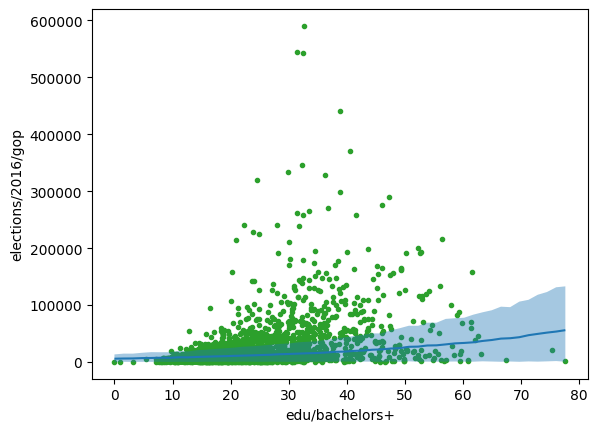

In [13]:
bmb.interpret.plot_predictions(model_counties_all, idata_counties_all, "edu/bachelors+", pps=True)
plt.plot(counties_final['edu/bachelors+'], counties_final['elections/2016/gop'], "C2.", zorder=-3)

not great definetly missed the curve in the middle, Im going to make a normal model. Since this looks like a normal curve.

In [ ]:
counties_modeln_data = counties_final.dropna().copy()
counties_modeln_data['elections/2016/gop'] = counties_model_data['elections/2016/gop'].astype(int)

modeln_counties_all = bmb.Model(
    "`elections/2016/gop` ~ `elections/2016/total` + `avg_income` + `bls/2020/unemployed` + `life-expectancy` + `poverty-rate` + `cost-of-living/living_wage` + `health/Violent Crime Rate` + `edu/bachelors+` ",
    counties_model_data, family="gaussian")
idatan_counties_all = modeln_counties_all.fit(idata_kwargs={"log_likelihood":True}, init='adapt_diag')

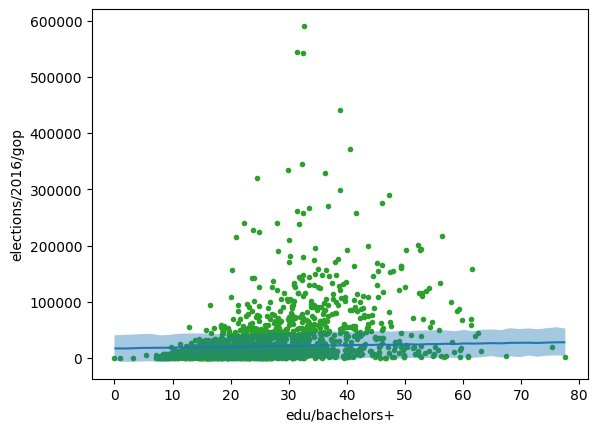

In [15]:
bmb.interpret.plot_predictions(modeln_counties_all, idatan_counties_all, "edu/bachelors+", pps=True)
plt.plot(counties_final['edu/bachelors+'], counties_final['elections/2016/gop'], "C2.", zorder=-3)

looks a little less linear but not much better. Next I will see if I can get one with interactions to run and see if that model performs any better.

In [ ]:
counties_model_data = counties_final.dropna().copy()
counties_model_data['elections/2016/gop'] = counties_model_data['elections/2016/gop'].astype(int)

modeln_counties_allinter = bmb.Model(
    "`elections/2016/gop` ~ `elections/2016/total` + `avg_income` + `bls/2020/unemployed` + `life-expectancy` + `poverty-rate` + `cost-of-living/living_wage` + `health/Violent Crime Rate` + `edu/bachelors+` + `bls/2020/unemployed`:`avg_income` + `bls/2020/unemployed`:`life-expectancy` +`bls/2020/unemployed`:`poverty-rate` + `edu/bachelors+`:`avg_income` + `avg_income`:`poverty-rate` ",
    counties_model_data, family="gaussian")
idatan_counties_allinter = modeln_counties_allinter.fit(idata_kwargs={"log_likelihood":True}, init='adapt_diag')

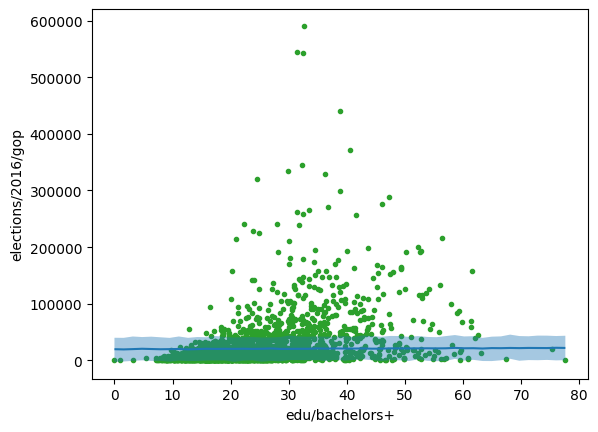

In [17]:
bmb.interpret.plot_predictions(modeln_counties_allinter, idatan_counties_allinter, "edu/bachelors+", pps=True)
plt.plot(counties_final['edu/bachelors+'], counties_final['elections/2016/gop'], "C2.", zorder=-3)

all these models are pretty bad. Which one is the best of the wourst?

In [18]:
cmp_bmb = az.compare( {"nb_all":idata_counties_all,"g_all":idatan_counties_all,"g_allinter":idatan_counties_allinter} )
cmp_bmb

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
nb_all,0,-30056.858907,26.430940,0.000000,0.818306,87.285171,0.000000,True,log
g_allinter,1,-31703.403110,207.355226,1646.544204,0.179275,327.520099,295.490826,True,log
g_all,2,-32024.449201,117.124952,1967.590294,0.002419,313.898076,281.651494,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

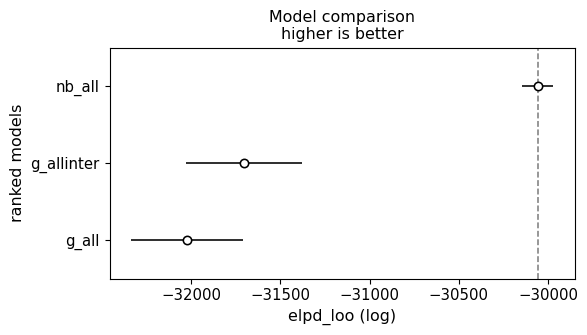

In [19]:
az.plot_compare(cmp_bmb)

 Gaussian Process model:

In [20]:
counties = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')

#convert from pandas to numpy array
GOP_wins = counties["elections/2016/gop"].values
edu = counties["edu/bachelors+"].values[:,None]

In [ ]:
!pip install preliz

In [22]:
#ig stands for inverse gamma
import preliz as pz
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [ ]:
with pm.Model() as model_cgp:
    #prior for our smoothness parameter
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(edu))

    #this is our kernal, which decides how our points relate to one another
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    #this specfices that we're using an HSGP
    gp = pm.gp.HSGP(m=[168], c=8.0, cov_func=cov)

    #f is for function, as in the function we use to transform our data
    f = gp.prior('f', X=edu)
    #prior for the neg binomial
    α = pm.HalfNormal('α', 1)
    #likelihood
    y = pm.Normal("y", mu=np.exp(f), sigma=α, observed=GOP_wins)

    idata_cgp = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_cgp,model_cgp, extend_inferencedata=True)

<Axes: xlabel='y_observed'>

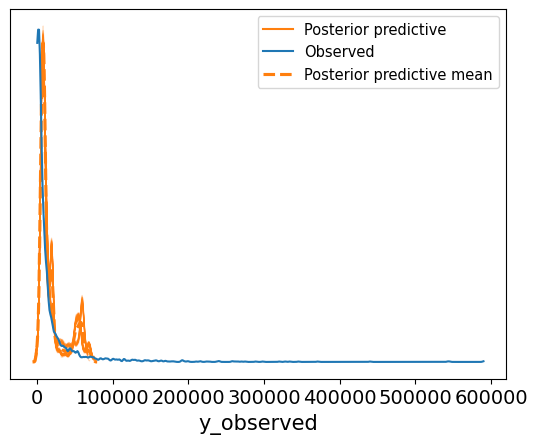

In [26]:
az.plot_ppc(idata_cgp, num_pp_samples=100, colors=["C1", "C0", "C1"])

looks a lot better than previous models!!

BART model:

(array([2.887e+03, 1.390e+02, 5.100e+01, 1.500e+01, 1.000e+01, 5.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 3.000e+00]),
 array([5.700000e+01, 5.909780e+04, 1.181386e+05, 1.771794e+05,
        2.362202e+05, 2.952610e+05, 3.543018e+05, 4.133426e+05,
        4.723834e+05, 5.314242e+05, 5.904650e+05]),
 <BarContainer object of 10 artists>)

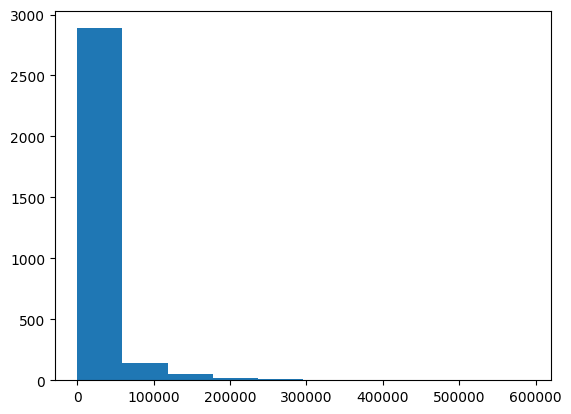

In [28]:
plt.hist(counties_final['elections/2016/gop'])

In [33]:
X = counties_model_data[[
             'elections/2016/total',
             'avg_income',
             'bls/2020/unemployed',
             'life-expectancy',
             'poverty-rate',
             'cost-of-living/living_wage',
             'health/Violent Crime Rate',
             'edu/bachelors+'
             ]]
#Define my estimand as Y
Y = counties_model_data['elections/2016/gop']

In [ ]:
with pm.Model() as model_cbart:
    s = pm.HalfNormal('s',1000)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_cbart = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_cbart,model_cbart, extend_inferencedata=True)

<Axes: xlabel='y'>

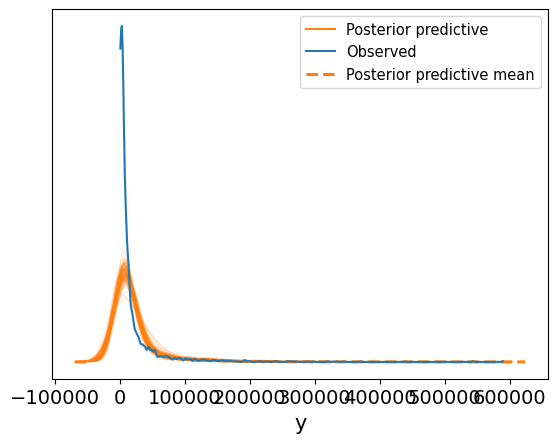

In [37]:
az.plot_ppc(idata_cbart, num_pp_samples=100, colors=["C1", "C0", "C1"])

This looks really bad, on second thought my data looks more exponential than normal so I tried that next.

In [ ]:
with pm.Model() as model_cbarte:
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Exponential("y", scale=μ, observed=Y)
    idata_cbarte = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_cbarte,model_cbarte, extend_inferencedata=True)

<Axes: xlabel='y'>

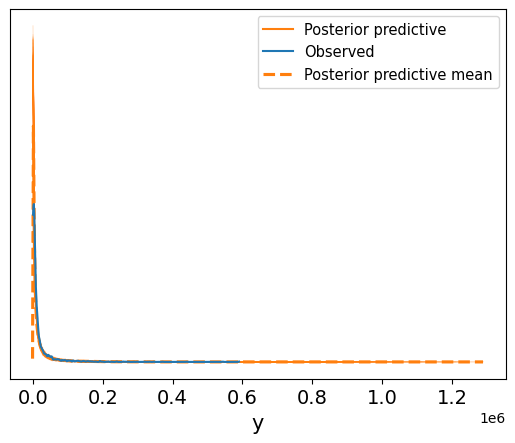

In [42]:
az.plot_ppc(idata_cbarte, num_pp_samples=100, colors=["C1", "C0", "C1"])


Looks alot better!!

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='elections/2016/total'>, <Axes: xlabel='avg_income'>,
       <Axes: xlabel='bls/2020/unemployed'>,
       <Axes: xlabel='life-expectancy'>, <Axes: xlabel='poverty-rate'>,
       <Axes: xlabel='cost-of-living/living_wage'>,
       <Axes: xlabel='health/Violent Crime Rate'>,
       <Axes: xlabel='edu/bachelors+'>], dtype=object)

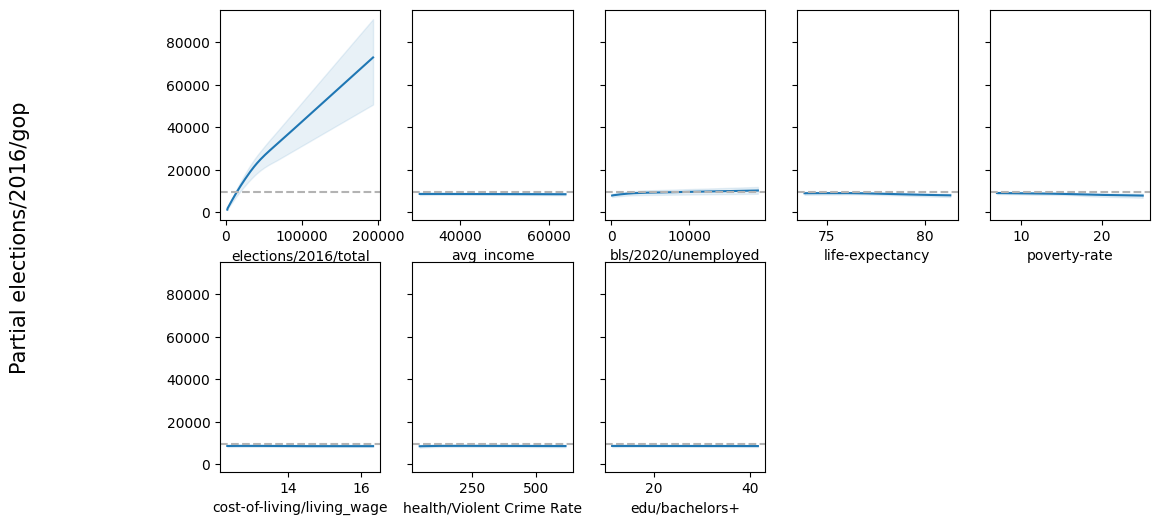

In [43]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))